In [154]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split as tts
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV as gs
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

LOADING DATA

In [112]:
data = pd.read_csv("adult.csv")

In [113]:
data

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [114]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   age              48842 non-null  int64
 1   workclass        48842 non-null  str  
 2   fnlwgt           48842 non-null  int64
 3   education        48842 non-null  str  
 4   educational-num  48842 non-null  int64
 5   marital-status   48842 non-null  str  
 6   occupation       48842 non-null  str  
 7   relationship     48842 non-null  str  
 8   race             48842 non-null  str  
 9   gender           48842 non-null  str  
 10  capital-gain     48842 non-null  int64
 11  capital-loss     48842 non-null  int64
 12  hours-per-week   48842 non-null  int64
 13  native-country   48842 non-null  str  
 14  income           48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 5.6 MB


One Hot Encoding

In [115]:
data = pd.concat([data.drop("occupation",axis=1),pd.get_dummies(data.occupation).add_prefix("occupation_")],axis=1)
data = pd.concat([data.drop("workclass",axis=1),pd.get_dummies(data.workclass).add_prefix("workclass_")],axis=1)
data = pd.concat([data.drop("marital-status",axis=1),pd.get_dummies(data["marital-status"]).add_prefix("marital-status_")],axis=1)
data = pd.concat([data.drop("relationship",axis=1),pd.get_dummies(data.relationship).add_prefix("relationship_")],axis=1)
data = pd.concat([data.drop("race",axis=1),pd.get_dummies(data.race).add_prefix("race_")],axis=1)
data = pd.concat([data.drop("native-country",axis=1),pd.get_dummies(data["native-country"]).add_prefix("native-country")],axis=1)
data = data.drop("education", axis=1)
data = data.drop("fnlwgt", axis=1)

In [116]:
data

,age,educational-num,gender,capital-gain,capital-loss,hours-per-week,income,occupation_?,occupation_Adm-clerical,occupation_Armed-Forces,...,native-countryPortugal,native-countryPuerto-Rico,native-countryScotland,native-countrySouth,native-countryTaiwan,native-countryThailand,native-countryTrinadad&Tobago,native-countryUnited-States,native-countryVietnam,native-countryYugoslavia
0,25,7,Male,0,0,40,<=50K,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,38,9,Male,0,0,50,<=50K,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,28,12,Male,0,0,40,>50K,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,44,10,Male,7688,0,40,>50K,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,18,10,Female,0,0,30,<=50K,True,False,False,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,12,Female,0,0,38,<=50K,False,False,False,...,False,False,False,False,False,False,False,True,False,False
48838,40,9,Male,0,0,40,>50K,False,False,False,...,False,False,False,False,False,False,False,True,False,False
48839,58,9,Female,0,0,40,<=50K,False,True,False,...,False,False,False,False,False,False,False,True,False,False
48840,22,9,Male,0,0,20,<=50K,False,True,False,...,False,False,False,False,False,False,False,True,False,False


In [117]:
#gender encoding and income encoding
data["gender"]=data["gender"].apply(lambda x : 1 if x =="Male" else 0)
data["income"]=data["income"].apply(lambda x : 1 if x ==">50K" else 0)
data.rename(columns={"gender":"gender_Male","income":"income>50K"}, inplace=True)

In [118]:
data

,age,educational-num,gender_Male,capital-gain,capital-loss,hours-per-week,income>50K,occupation_?,occupation_Adm-clerical,occupation_Armed-Forces,...,native-countryPortugal,native-countryPuerto-Rico,native-countryScotland,native-countrySouth,native-countryTaiwan,native-countryThailand,native-countryTrinadad&Tobago,native-countryUnited-States,native-countryVietnam,native-countryYugoslavia
0,25,7,1,0,0,40,0,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,38,9,1,0,0,50,0,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,28,12,1,0,0,40,1,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,44,10,1,7688,0,40,1,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,18,10,0,0,0,30,0,True,False,False,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,12,0,0,0,38,0,False,False,False,...,False,False,False,False,False,False,False,True,False,False
48838,40,9,1,0,0,40,1,False,False,False,...,False,False,False,False,False,False,False,True,False,False
48839,58,9,0,0,0,40,0,False,True,False,...,False,False,False,False,False,False,False,True,False,False
48840,22,9,1,0,0,20,0,False,True,False,...,False,False,False,False,False,False,False,True,False,False


array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'educational-num'}>,
        <Axes: title={'center': 'gender_Male'}>],
       [<Axes: title={'center': 'capital-gain'}>,
        <Axes: title={'center': 'capital-loss'}>,
        <Axes: title={'center': 'hours-per-week'}>],
       [<Axes: title={'center': 'income>50K'}>, <Axes: >, <Axes: >]],
      dtype=object)

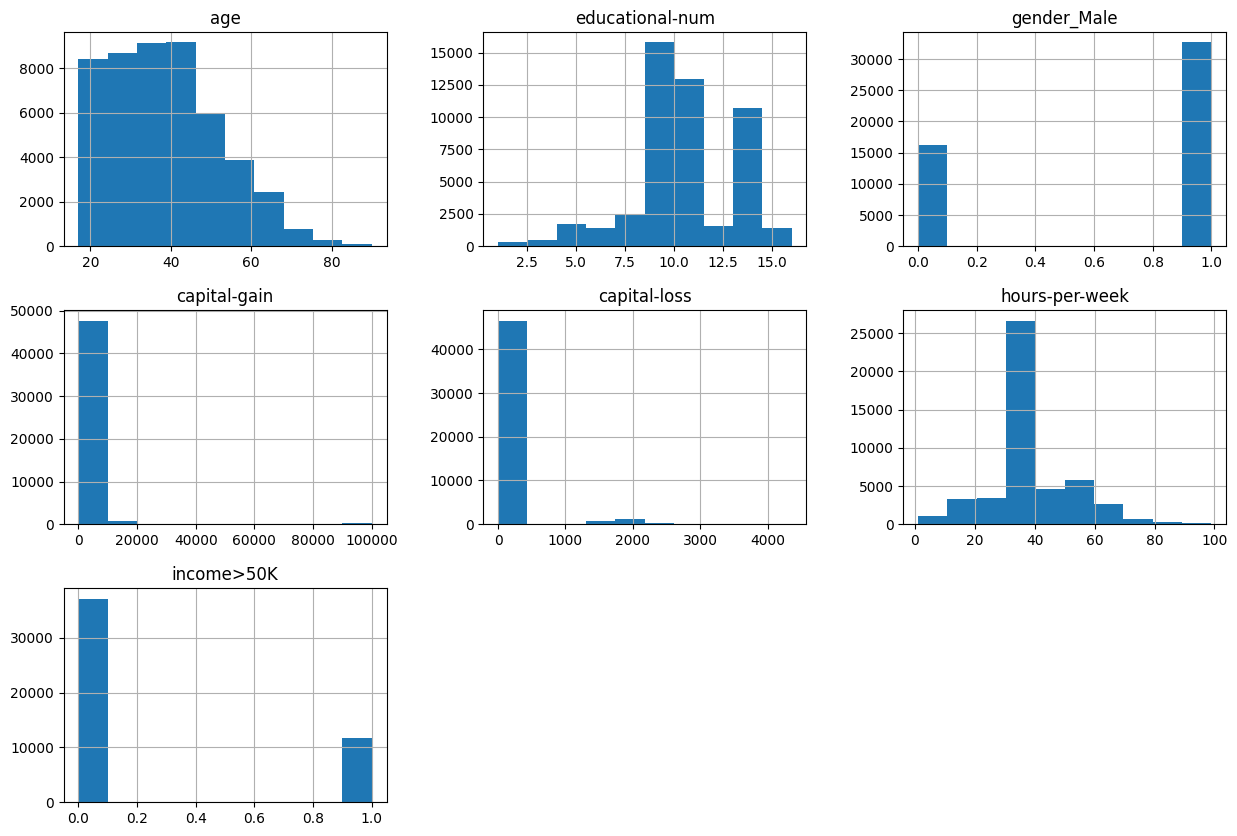

In [119]:
data.hist(figsize=(15,10)) 

<Axes: >

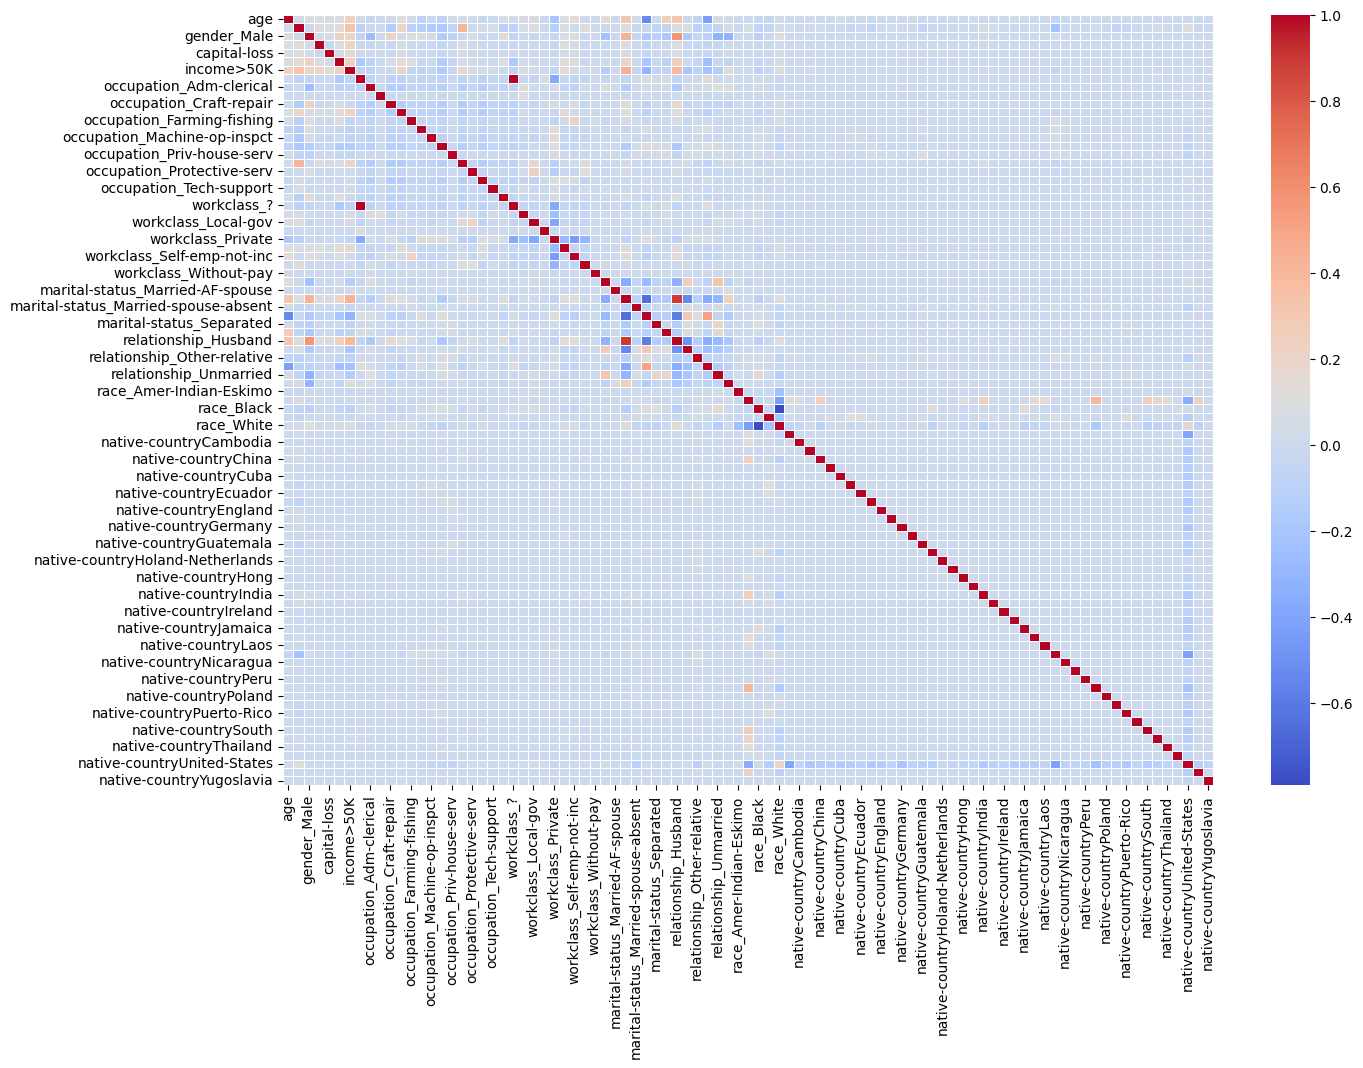

In [120]:
plt.figure(figsize=(15,10))
sns.heatmap(data.corr(numeric_only = True),annot=False,cmap="coolwarm",  linewidths=0.5)

In [121]:
data.corr(numeric_only = True)['income>50K']

age                              0.230369
educational-num                  0.332613
gender_Male                      0.214628
capital-gain                     0.223013
capital-loss                     0.147554
                                   ...   
native-countryThailand          -0.004219
native-countryTrinadad&Tobago   -0.009107
native-countryUnited-States      0.032551
native-countryVietnam           -0.015542
native-countryYugoslavia         0.005522
Name: income>50K, Length: 91, dtype: float64

FILTERING

In [122]:
correlations=data.corr(numeric_only = True)['income>50K'].abs()
sorted_correlations = correlations.sort_values()
sorted_correlations

native-countryCuba                   0.000885
native-countryHong                   0.001591
native-countryHoland-Netherlands     0.002538
native-countryHungary                0.003538
native-countryIreland                0.003744
                                       ...   
marital-status_Never-married         0.318782
educational-num                      0.332613
relationship_Husband                 0.403791
marital-status_Married-civ-spouse    0.445853
income>50K                           1.000000
Name: income>50K, Length: 91, dtype: float64

In [123]:
num_col_to_drop = int(0.8 * len(data.columns))
num_col_to_drop

72

In [124]:
col_to_drop = sorted_correlations.iloc[:num_col_to_drop].index
col_to_drop

Index(['native-countryCuba', 'native-countryHong',
       'native-countryHoland-Netherlands', 'native-countryHungary',
       'native-countryIreland', 'occupation_Armed-Forces',
       'native-countryThailand', 'native-countryPoland',
       'native-countryCambodia', 'native-countryScotland',
       'native-countryPortugal', 'native-country?', 'native-countryYugoslavia',
       'native-countryGermany', 'native-countryChina',
       'native-countryHonduras', 'workclass_Without-pay',
       'native-countrySouth', 'native-countryEcuador', 'native-countryLaos',
       'workclass_Never-worked', 'native-countryPhilippines',
       'marital-status_Married-AF-spouse', 'native-countryTrinadad&Tobago',
       'native-countryItaly', 'native-countryGreece',
       'native-countryOutlying-US(Guam-USVI-etc)', 'native-countryJamaica',
       'native-countryIran', 'native-countryPeru', 'native-countryHaiti',
       'native-countryJapan', 'occupation_Craft-repair',
       'native-countryFrance', 'race_

In [125]:
data_dropped = data.drop(col_to_drop,axis=1)
data_dropped

,age,educational-num,gender_Male,capital-gain,capital-loss,hours-per-week,income>50K,occupation_Exec-managerial,occupation_Other-service,occupation_Prof-specialty,workclass_Self-emp-inc,marital-status_Divorced,marital-status_Married-civ-spouse,marital-status_Never-married,relationship_Husband,relationship_Not-in-family,relationship_Own-child,relationship_Unmarried,relationship_Wife
0,25,7,1,0,0,40,0,False,False,False,False,False,False,True,False,False,True,False,False
1,38,9,1,0,0,50,0,False,False,False,False,False,True,False,True,False,False,False,False
2,28,12,1,0,0,40,1,False,False,False,False,False,True,False,True,False,False,False,False
3,44,10,1,7688,0,40,1,False,False,False,False,False,True,False,True,False,False,False,False
4,18,10,0,0,0,30,0,False,False,False,False,False,False,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,12,0,0,0,38,0,False,False,False,False,False,True,False,False,False,False,False,True
48838,40,9,1,0,0,40,1,False,False,False,False,False,True,False,True,False,False,False,False
48839,58,9,0,0,0,40,0,False,False,False,False,False,False,False,False,False,False,True,False
48840,22,9,1,0,0,20,0,False,False,False,False,False,False,True,False,False,True,False,False


<Axes: >

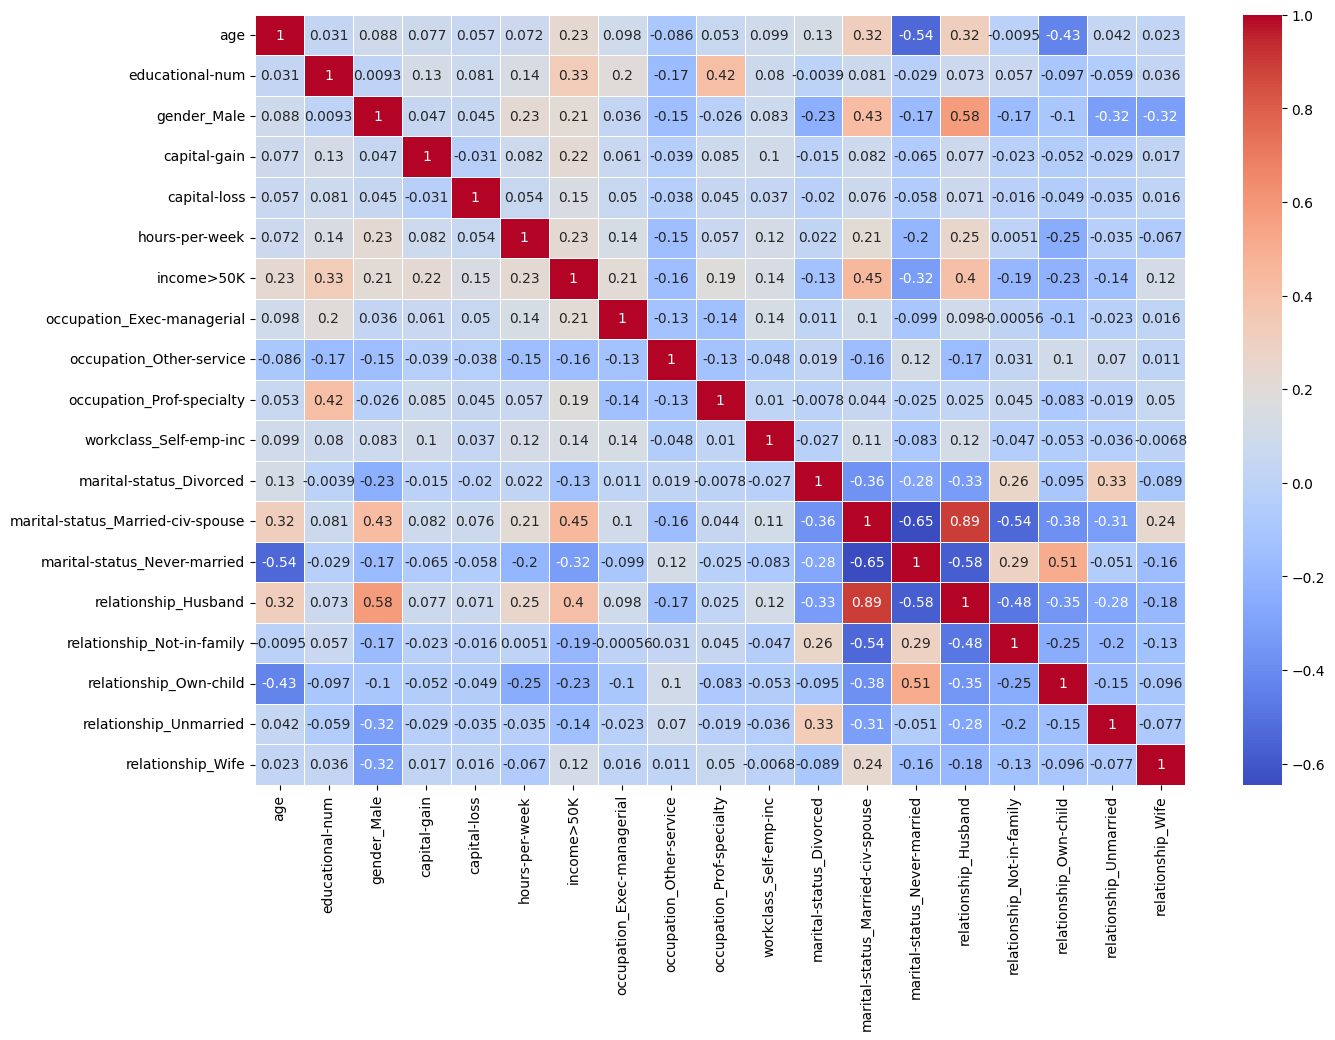

In [126]:
plt.figure(figsize=(15,10))
sns.heatmap(data_dropped.corr(numeric_only = True),annot=True,cmap="coolwarm",  linewidths=0.5)

In [127]:
#Decision-Tree Nature of Data: The dataset consists primarily of categorical and binary features (e.g., gender, marital status, or occupation). Since a decision tree relies on branching nodes (yes/no decisions) to reach a conclusion, the model is a very natural fit for this type of data.
#Ensemble Power: A Random Forest is an ensemble of multiple decision trees, which makes the overall model significantly more robust and powerful than a single decision tree alone.
#Efficiency: Because the problem is a binary classification task (predicting whether income is above or below 50K), the structure of the Random Forest handles these logic-based splits effectively without requiring complex data scaling in many cases.

train_data,test_data =tts(data,test_size=0.2)

In [128]:
X_train=train_data.drop("income>50K",axis=1)
y_train=train_data["income>50K"]
X_test=test_data.drop("income>50K",axis=1)
y_test=test_data["income>50K"]

In [129]:
Forest = RandomForestClassifier()
Forest.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [130]:
Forest.score(X_test,y_test)

0.8467601596888116

In [131]:
importance = pd.Series(
    Forest.feature_importances_,
    index=X_train.columns
)

print(importance.sort_values(ascending=False))

age                                         0.225193
educational-num                             0.130964
hours-per-week                              0.113234
capital-gain                                0.109288
marital-status_Married-civ-spouse           0.074416
                                              ...   
native-countryOutlying-US(Guam-USVI-etc)    0.000037
native-countryHonduras                      0.000029
occupation_Armed-Forces                     0.000023
workclass_Never-worked                      0.000001
native-countryHoland-Netherlands            0.000000
Length: 90, dtype: float64


In [133]:
param_grid = {
    "n_estimators": [100,200,300],
    "max_depth":[20,30,40],
    "min_samples_split":[2,4,5]
}
gridsearch = gs(RandomForestClassifier(),param_grid,cv=5,return_train_score=True,verbose=10)
gridsearch.fit(X_train,y_train)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
[CV 1/5; 1/27] START max_depth=20, min_samples_split=2, n_estimators=100........
[CV 1/5; 1/27] END max_depth=20, min_samples_split=2, n_estimators=100;, score=(train=0.909, test=0.865) total time=   3.5s
[CV 2/5; 1/27] START max_depth=20, min_samples_split=2, n_estimators=100........
[CV 2/5; 1/27] END max_depth=20, min_samples_split=2, n_estimators=100;, score=(train=0.909, test=0.858) total time=   3.5s
[CV 3/5; 1/27] START max_depth=20, min_samples_split=2, n_estimators=100........
[CV 3/5; 1/27] END max_depth=20, min_samples_split=2, n_estimators=100;, score=(train=0.911, test=0.867) total time=   3.5s
[CV 4/5; 1/27] START max_depth=20, min_samples_split=2, n_estimators=100........
[CV 4/5; 1/27] END max_depth=20, min_samples_split=2, n_estimators=100;, score=(train=0.909, test=0.867) total time=   3.5s
[CV 5/5; 1/27] START max_depth=20, min_samples_split=2, n_estimators=100........
[CV 5/5; 1/27] END max_depth=20, min_

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [20, 30, ...], 'min_samples_split': [2, 4, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : t

In [134]:
final_model=gridsearch.best_estimator_
final_model.score(X_test,y_test)

0.8630361347118436

In [135]:
importance = pd.Series(
    final_model.feature_importances_,
    index=X_train.columns
)

print(importance.sort_values(ascending=False))

capital-gain                                0.163691
educational-num                             0.137966
marital-status_Married-civ-spouse           0.115446
age                                         0.093295
relationship_Husband                        0.075522
                                              ...   
native-countryOutlying-US(Guam-USVI-etc)    0.000029
native-countryHonduras                      0.000025
occupation_Armed-Forces                     0.000019
workclass_Never-worked                      0.000002
native-countryHoland-Netherlands            0.000001
Length: 90, dtype: float64


In [136]:
with open("income_prediction","wb") as f:
    pickle.dump(final_model.feature_importances_,f)

In [144]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.95      0.91      7417
           1       0.79      0.59      0.68      2352

    accuracy                           0.86      9769
   macro avg       0.83      0.77      0.79      9769
weighted avg       0.86      0.86      0.86      9769



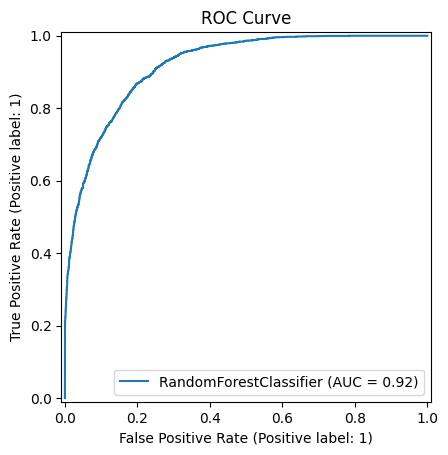

In [145]:
RocCurveDisplay.from_estimator(
    final_model,
    X_test,
    y_test
)

plt.title("ROC Curve")

plt.show()

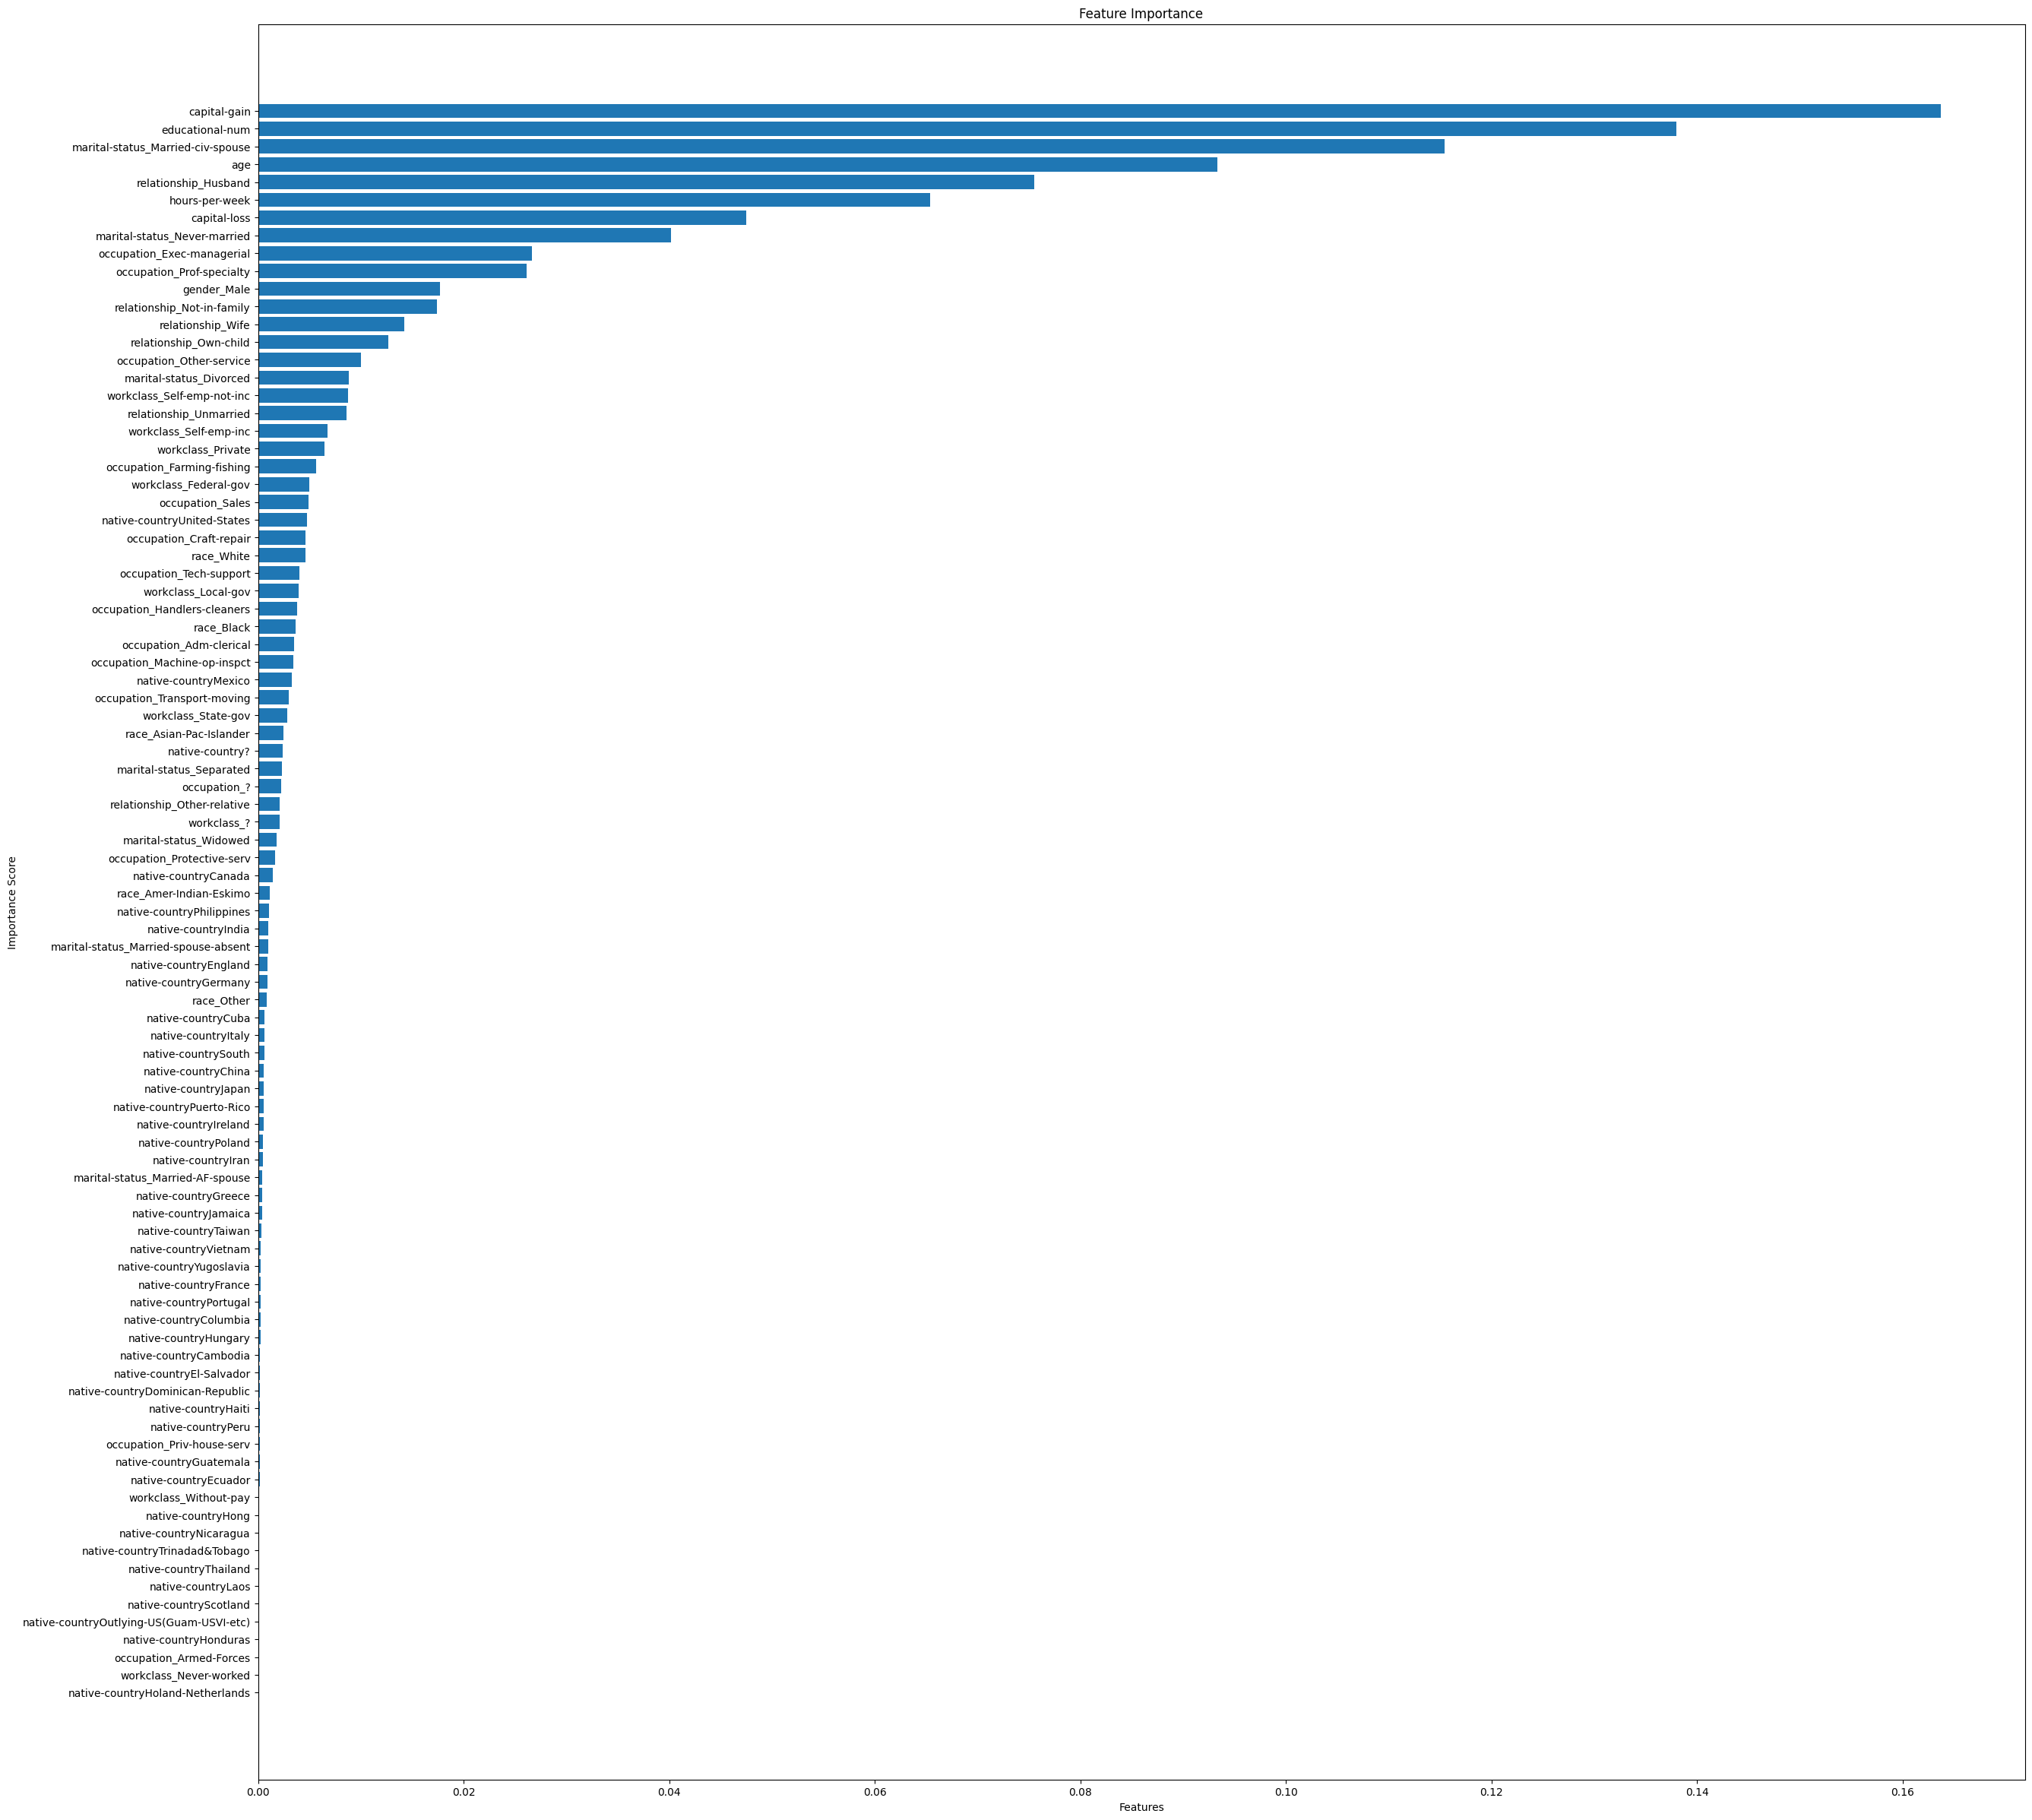

In [156]:
importance =importance.sort_values()
plt.figure(figsize=(30,30))

plt.barh(importance.index,
        importance.values)

plt.xticks()

plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.title("Feature Importance")

plt.show()

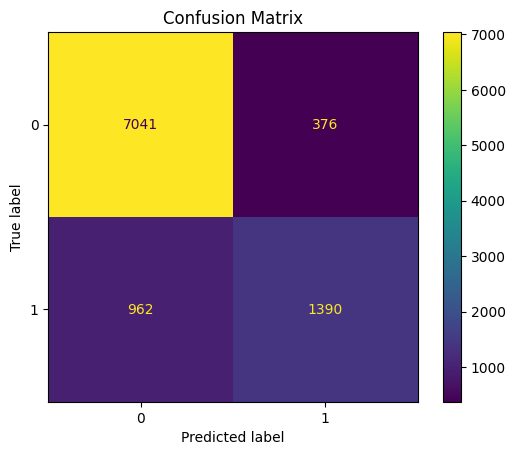

In [155]:
y_pred = final_model.predict(X_test)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.title("Confusion Matrix")

plt.show()